In [379]:
from scipy.io import arff
import pandas as pd
import os
import plotly.express as px
import numpy as np

## 0. Import Data and initial inspection

In [118]:
data, met = arff.loadarff("emotions/emotions.arff")

In [120]:
df_emotions = pd.DataFrame(data)

In [122]:
df_emotions.head()

,Mean_Acc1298_Mean_Mem40_Centroid,Mean_Acc1298_Mean_Mem40_Rolloff,Mean_Acc1298_Mean_Mem40_Flux,Mean_Acc1298_Mean_Mem40_MFCC_0,Mean_Acc1298_Mean_Mem40_MFCC_1,Mean_Acc1298_Mean_Mem40_MFCC_2,Mean_Acc1298_Mean_Mem40_MFCC_3,Mean_Acc1298_Mean_Mem40_MFCC_4,Mean_Acc1298_Mean_Mem40_MFCC_5,Mean_Acc1298_Mean_Mem40_MFCC_6,...,BH_HighLowRatio,BHSUM1,BHSUM2,BHSUM3,amazed-suprised,happy-pleased,relaxing-calm,quiet-still,sad-lonely,angry-aggresive
0,0.034741,0.089665,0.091225,-73.302422,6.215179,0.615074,2.037160,0.804065,1.301409,0.558576,...,2.0,0.245457,0.105065,0.405399,b'0',b'1',b'1',b'0',b'0',b'0'
1,0.081374,0.272747,0.085733,-62.584437,3.183163,-0.218145,0.163038,0.620251,0.458514,0.041426,...,2.0,0.343547,0.276366,0.710924,b'1',b'0',b'0',b'0',b'0',b'1'
2,0.110545,0.273567,0.084410,-65.235325,2.794964,0.639047,1.281297,0.757896,0.489412,0.627636,...,3.0,0.188693,0.045941,0.457372,b'0',b'1',b'0',b'0',b'0',b'1'
3,0.042481,0.199281,0.093447,-80.305152,5.824409,0.648848,1.754870,1.495532,0.739909,0.809644,...,2.0,0.102839,0.241934,0.351009,b'0',b'0',b'1',b'0',b'0',b'0'
4,0.074550,0.140880,0.079789,-93.697749,5.543229,1.064262,0.899152,0.890336,0.702328,0.490685,...,2.0,0.195196,0.310801,0.683817,b'0',b'0',b'0',b'1',b'0',b'0'


In [124]:
df_emotions.shape

(593, 78)

In [126]:
df_emotions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593 entries, 0 to 592
Data columns (total 78 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Mean_Acc1298_Mean_Mem40_Centroid  593 non-null    float64
 1   Mean_Acc1298_Mean_Mem40_Rolloff   593 non-null    float64
 2   Mean_Acc1298_Mean_Mem40_Flux      593 non-null    float64
 3   Mean_Acc1298_Mean_Mem40_MFCC_0    593 non-null    float64
 4   Mean_Acc1298_Mean_Mem40_MFCC_1    593 non-null    float64
 5   Mean_Acc1298_Mean_Mem40_MFCC_2    593 non-null    float64
 6   Mean_Acc1298_Mean_Mem40_MFCC_3    593 non-null    float64
 7   Mean_Acc1298_Mean_Mem40_MFCC_4    593 non-null    float64
 8   Mean_Acc1298_Mean_Mem40_MFCC_5    593 non-null    float64
 9   Mean_Acc1298_Mean_Mem40_MFCC_6    593 non-null    float64
 10  Mean_Acc1298_Mean_Mem40_MFCC_7    593 non-null    float64
 11  Mean_Acc1298_Mean_Mem40_MFCC_8    593 non-null    float64
 12  Mean_Acc

In [128]:
df_emotions.describe(include="all")

,Mean_Acc1298_Mean_Mem40_Centroid,Mean_Acc1298_Mean_Mem40_Rolloff,Mean_Acc1298_Mean_Mem40_Flux,Mean_Acc1298_Mean_Mem40_MFCC_0,Mean_Acc1298_Mean_Mem40_MFCC_1,Mean_Acc1298_Mean_Mem40_MFCC_2,Mean_Acc1298_Mean_Mem40_MFCC_3,Mean_Acc1298_Mean_Mem40_MFCC_4,Mean_Acc1298_Mean_Mem40_MFCC_5,Mean_Acc1298_Mean_Mem40_MFCC_6,...,BH_HighLowRatio,BHSUM1,BHSUM2,BHSUM3,amazed-suprised,happy-pleased,relaxing-calm,quiet-still,sad-lonely,angry-aggresive
count,593.000000,593.000000,593.000000,593.000000,593.000000,593.000000,593.000000,593.000000,593.000000,593.000000,...,593.000000,593.000000,593.000000,593.000000,593,593,593,593,593,593
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2,2,2,2,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,b'0',b'0',b'0',b'0',b'0',b'0'
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,420,427,329,445,425,404
mean,0.069309,0.195399,0.085695,-72.998228,4.979178,0.602395,1.694625,0.634156,0.833964,0.508060,...,2.099494,0.412940,0.354901,0.959906,NaN,NaN,NaN,NaN,NaN,NaN
std,0.031293,0.117605,0.009260,7.580804,2.071792,1.017603,0.606581,0.448746,0.368312,0.303277,...,0.316040,0.339559,0.362262,0.651827,NaN,NaN,NaN,NaN,NaN,NaN
min,0.010201,0.038286,0.070932,-99.090802,0.051474,-2.277307,-0.604609,-1.143864,-0.237114,-0.444623,...,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.044781,0.107742,0.079018,-77.078349,3.409922,-0.113441,1.307242,0.373195,0.605057,0.309033,...,2.000000,0.179411,0.099424,0.513974,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.065251,0.169757,0.083637,-72.474302,4.642338,0.588380,1.731031,0.618838,0.819652,0.534665,...,2.000000,0.309902,0.246193,0.804229,NaN,NaN,NaN,NaN,NaN,NaN
75%,0.086290,0.257668,0.091323,-68.292848,6.439446,1.293202,2.072488,0.925091,1.051206,0.708430,...,2.000000,0.529859,0.472593,1.242089,NaN,NaN,NaN,NaN,NaN,NaN


In [144]:
df_emotions.duplicated().sum()

0

In [146]:
df_emotions.isnull().sum()

Mean_Acc1298_Mean_Mem40_Centroid    0
Mean_Acc1298_Mean_Mem40_Rolloff     0
Mean_Acc1298_Mean_Mem40_Flux        0
Mean_Acc1298_Mean_Mem40_MFCC_0      0
Mean_Acc1298_Mean_Mem40_MFCC_1      0
                                   ..
happy-pleased                       0
relaxing-calm                       0
quiet-still                         0
sad-lonely                          0
angry-aggresive                     0
Length: 78, dtype: int64

## 1. EDA

In [131]:
type(df_emotions['happy-pleased'].iloc[0])

bytes

In [133]:
#change type of byte variables to string - Yes or No
emo_cols = [
    'amazed-suprised',
    'happy-pleased',
    'relaxing-calm',
    'quiet-still',
    'sad-lonely',
    'angry-aggresive'
]
    
for col in emo_cols:
    df_emotions[col] = df_emotions[col].str.decode('utf-8')

    df_emotions[col] = df_emotions[col].map(
        {'0': 'No',
        '1': 'Yes'}
    )
                                            


In [135]:
type(df_emotions['happy-pleased'].iloc[0])

str

In [137]:
df_emotions.head()

,Mean_Acc1298_Mean_Mem40_Centroid,Mean_Acc1298_Mean_Mem40_Rolloff,Mean_Acc1298_Mean_Mem40_Flux,Mean_Acc1298_Mean_Mem40_MFCC_0,Mean_Acc1298_Mean_Mem40_MFCC_1,Mean_Acc1298_Mean_Mem40_MFCC_2,Mean_Acc1298_Mean_Mem40_MFCC_3,Mean_Acc1298_Mean_Mem40_MFCC_4,Mean_Acc1298_Mean_Mem40_MFCC_5,Mean_Acc1298_Mean_Mem40_MFCC_6,...,BH_HighLowRatio,BHSUM1,BHSUM2,BHSUM3,amazed-suprised,happy-pleased,relaxing-calm,quiet-still,sad-lonely,angry-aggresive
0,0.034741,0.089665,0.091225,-73.302422,6.215179,0.615074,2.037160,0.804065,1.301409,0.558576,...,2.0,0.245457,0.105065,0.405399,No,Yes,Yes,No,No,No
1,0.081374,0.272747,0.085733,-62.584437,3.183163,-0.218145,0.163038,0.620251,0.458514,0.041426,...,2.0,0.343547,0.276366,0.710924,Yes,No,No,No,No,Yes
2,0.110545,0.273567,0.084410,-65.235325,2.794964,0.639047,1.281297,0.757896,0.489412,0.627636,...,3.0,0.188693,0.045941,0.457372,No,Yes,No,No,No,Yes
3,0.042481,0.199281,0.093447,-80.305152,5.824409,0.648848,1.754870,1.495532,0.739909,0.809644,...,2.0,0.102839,0.241934,0.351009,No,No,Yes,No,No,No
4,0.074550,0.140880,0.079789,-93.697749,5.543229,1.064262,0.899152,0.890336,0.702328,0.490685,...,2.0,0.195196,0.310801,0.683817,No,No,No,Yes,No,No


In [148]:
df_emotions.columns.tolist()

['Mean_Acc1298_Mean_Mem40_Centroid',
 'Mean_Acc1298_Mean_Mem40_Rolloff',
 'Mean_Acc1298_Mean_Mem40_Flux',
 'Mean_Acc1298_Mean_Mem40_MFCC_0',
 'Mean_Acc1298_Mean_Mem40_MFCC_1',
 'Mean_Acc1298_Mean_Mem40_MFCC_2',
 'Mean_Acc1298_Mean_Mem40_MFCC_3',
 'Mean_Acc1298_Mean_Mem40_MFCC_4',
 'Mean_Acc1298_Mean_Mem40_MFCC_5',
 'Mean_Acc1298_Mean_Mem40_MFCC_6',
 'Mean_Acc1298_Mean_Mem40_MFCC_7',
 'Mean_Acc1298_Mean_Mem40_MFCC_8',
 'Mean_Acc1298_Mean_Mem40_MFCC_9',
 'Mean_Acc1298_Mean_Mem40_MFCC_10',
 'Mean_Acc1298_Mean_Mem40_MFCC_11',
 'Mean_Acc1298_Mean_Mem40_MFCC_12',
 'Mean_Acc1298_Std_Mem40_Centroid',
 'Mean_Acc1298_Std_Mem40_Rolloff',
 'Mean_Acc1298_Std_Mem40_Flux',
 'Mean_Acc1298_Std_Mem40_MFCC_0',
 'Mean_Acc1298_Std_Mem40_MFCC_1',
 'Mean_Acc1298_Std_Mem40_MFCC_2',
 'Mean_Acc1298_Std_Mem40_MFCC_3',
 'Mean_Acc1298_Std_Mem40_MFCC_4',
 'Mean_Acc1298_Std_Mem40_MFCC_5',
 'Mean_Acc1298_Std_Mem40_MFCC_6',
 'Mean_Acc1298_Std_Mem40_MFCC_7',
 'Mean_Acc1298_Std_Mem40_MFCC_8',
 'Mean_Acc1298_Std_Mem40_MF

In [150]:
num_cols = [
     'Mean_Acc1298_Mean_Mem40_Centroid',
     'Mean_Acc1298_Mean_Mem40_Rolloff',
     'Mean_Acc1298_Mean_Mem40_Flux',
     'Mean_Acc1298_Mean_Mem40_MFCC_0',
     'Mean_Acc1298_Mean_Mem40_MFCC_1',
     'Mean_Acc1298_Mean_Mem40_MFCC_2',
     'Mean_Acc1298_Mean_Mem40_MFCC_3',
     'Mean_Acc1298_Mean_Mem40_MFCC_4',
     'Mean_Acc1298_Mean_Mem40_MFCC_5',
     'Mean_Acc1298_Mean_Mem40_MFCC_6',
     'Mean_Acc1298_Mean_Mem40_MFCC_7',
     'Mean_Acc1298_Mean_Mem40_MFCC_8',
     'Mean_Acc1298_Mean_Mem40_MFCC_9',
     'Mean_Acc1298_Mean_Mem40_MFCC_10',
     'Mean_Acc1298_Mean_Mem40_MFCC_11',
     'Mean_Acc1298_Mean_Mem40_MFCC_12',
     'Mean_Acc1298_Std_Mem40_Centroid',
     'Mean_Acc1298_Std_Mem40_Rolloff',
     'Mean_Acc1298_Std_Mem40_Flux',
     'Mean_Acc1298_Std_Mem40_MFCC_0',
     'Mean_Acc1298_Std_Mem40_MFCC_1',
     'Mean_Acc1298_Std_Mem40_MFCC_2',
     'Mean_Acc1298_Std_Mem40_MFCC_3',
     'Mean_Acc1298_Std_Mem40_MFCC_4',
     'Mean_Acc1298_Std_Mem40_MFCC_5',
     'Mean_Acc1298_Std_Mem40_MFCC_6',
     'Mean_Acc1298_Std_Mem40_MFCC_7',
     'Mean_Acc1298_Std_Mem40_MFCC_8',
     'Mean_Acc1298_Std_Mem40_MFCC_9',
     'Mean_Acc1298_Std_Mem40_MFCC_10',
     'Mean_Acc1298_Std_Mem40_MFCC_11',
     'Mean_Acc1298_Std_Mem40_MFCC_12',
     'Std_Acc1298_Mean_Mem40_Centroid',
     'Std_Acc1298_Mean_Mem40_Rolloff',
     'Std_Acc1298_Mean_Mem40_Flux',
     'Std_Acc1298_Mean_Mem40_MFCC_0',
     'Std_Acc1298_Mean_Mem40_MFCC_1',
     'Std_Acc1298_Mean_Mem40_MFCC_2',
     'Std_Acc1298_Mean_Mem40_MFCC_3',
     'Std_Acc1298_Mean_Mem40_MFCC_4',
     'Std_Acc1298_Mean_Mem40_MFCC_5',
     'Std_Acc1298_Mean_Mem40_MFCC_6',
     'Std_Acc1298_Mean_Mem40_MFCC_7',
     'Std_Acc1298_Mean_Mem40_MFCC_8',
     'Std_Acc1298_Mean_Mem40_MFCC_9',
     'Std_Acc1298_Mean_Mem40_MFCC_10',
     'Std_Acc1298_Mean_Mem40_MFCC_11',
     'Std_Acc1298_Mean_Mem40_MFCC_12',
     'Std_Acc1298_Std_Mem40_Centroid',
     'Std_Acc1298_Std_Mem40_Rolloff',
     'Std_Acc1298_Std_Mem40_Flux',
     'Std_Acc1298_Std_Mem40_MFCC_0',
     'Std_Acc1298_Std_Mem40_MFCC_1',
     'Std_Acc1298_Std_Mem40_MFCC_2',
     'Std_Acc1298_Std_Mem40_MFCC_3',
     'Std_Acc1298_Std_Mem40_MFCC_4',
     'Std_Acc1298_Std_Mem40_MFCC_5',
     'Std_Acc1298_Std_Mem40_MFCC_6',
     'Std_Acc1298_Std_Mem40_MFCC_7',
     'Std_Acc1298_Std_Mem40_MFCC_8',
     'Std_Acc1298_Std_Mem40_MFCC_9',
     'Std_Acc1298_Std_Mem40_MFCC_10',
     'Std_Acc1298_Std_Mem40_MFCC_11',
     'Std_Acc1298_Std_Mem40_MFCC_12',
     'BH_LowPeakAmp',
     'BH_LowPeakBPM',
     'BH_HighPeakAmp',
     'BH_HighPeakBPM',
     'BH_HighLowRatio',
     'BHSUM1',
     'BHSUM2',
     'BHSUM3'
]

In [175]:
emo_counts = (
    df_emotions[emo_cols]
    .eq('Yes')
    .sum()
    .sort_values(ascending = False)
)

In [179]:
emo_counts

relaxing-calm      264
angry-aggresive    189
amazed-suprised    173
sad-lonely         168
happy-pleased      166
quiet-still        148
dtype: int64

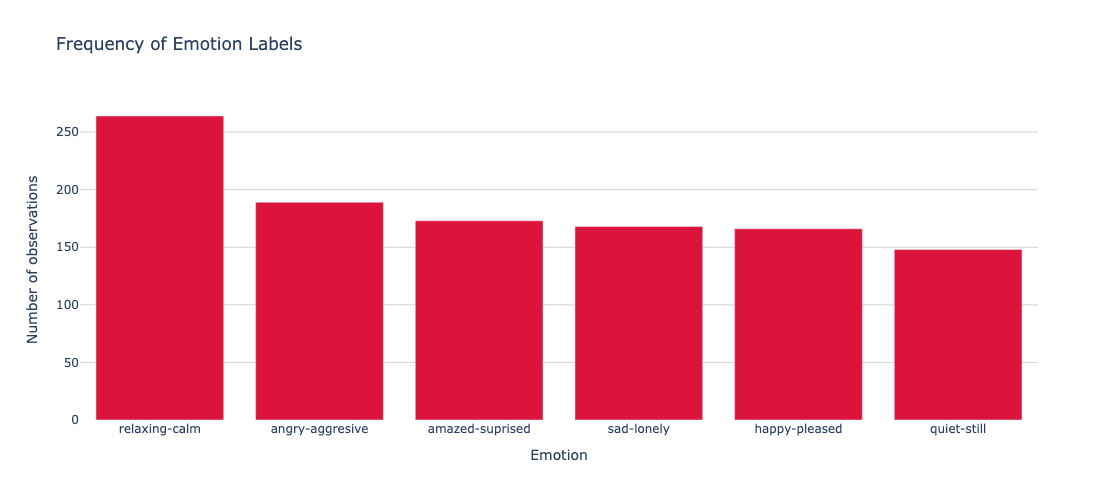

In [309]:
fig = px.bar(
    x=emo_counts.index,
    y=emo_counts.values,
    labels={
        'x': 'Emotion',
        'y': 'Number of observations'
    },
    title = 'Frequency of Emotion Labels',
    width=1100,
    height=500
    )
fig.update_traces(marker_color='crimson')
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.update_yaxes(
    showgrid=True,
    gridcolor='lightgray'
)
fig.show()

In [323]:
emo_binary = (
    df_emotions[emo_cols]
    .replace({'No': 0, 'Yes': 1})
    .infer_objects(copy=False) #replace will be deprecated as it is, so this safeguards the old results
)

/var/folders/g0/990px7q94zg1mm5vxhtzn72h0000gn/T/ipykernel_14704/278250047.py:3: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [327]:
#correlation
emo_corr = emo_binary.corr()
emo_corr

,amazed-suprised,happy-pleased,relaxing-calm,quiet-still,sad-lonely,angry-aggresive
amazed-suprised,1.000000,0.062565,-0.477873,-0.370126,-0.321184,0.293468
happy-pleased,0.062565,1.000000,0.129219,-0.298822,-0.383677,-0.329735
relaxing-calm,-0.477873,0.129219,1.000000,0.298812,0.152166,-0.561723
quiet-still,-0.370126,-0.298822,0.298812,1.000000,0.545410,-0.377725
sad-lonely,-0.321184,-0.383677,0.152166,0.545410,1.000000,-0.269406
angry-aggresive,0.293468,-0.329735,-0.561723,-0.377725,-0.269406,1.000000


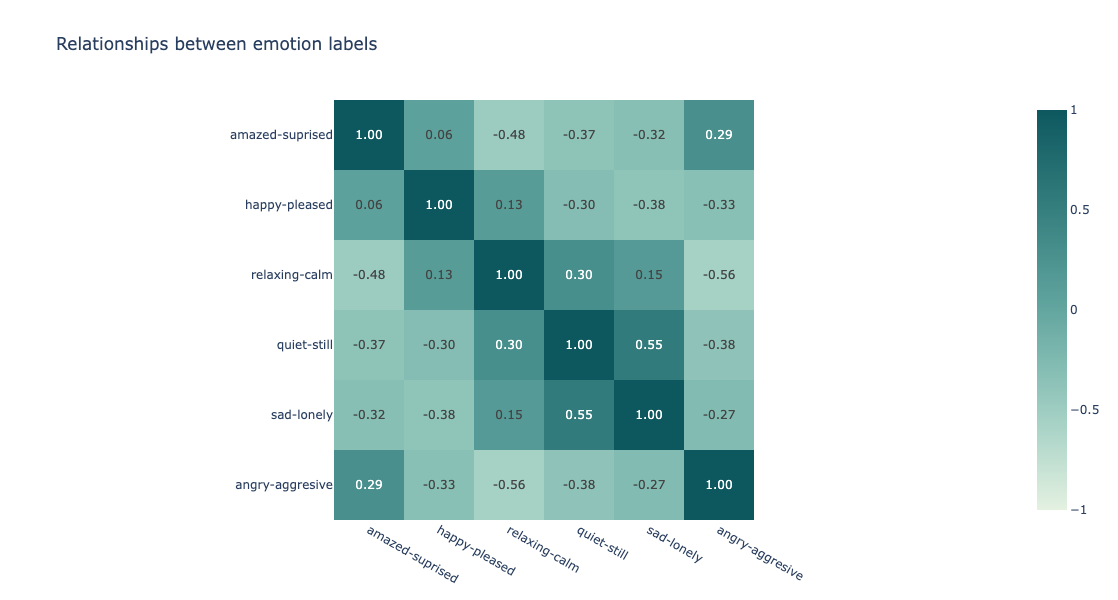

In [357]:
#heatmap
fig = px.imshow(
    emo_corr,
    text_auto='.2f',
    zmin=-1,
    zmax=1,
    color_continuous_scale='mint',
    title='Relationships between emotion labels',
    width=1100,
    height=600
)

fig.show()

In [367]:
num_corr = df_emotions[num_cols].corr()    
num_corr

,Mean_Acc1298_Mean_Mem40_Centroid,Mean_Acc1298_Mean_Mem40_Rolloff,Mean_Acc1298_Mean_Mem40_Flux,Mean_Acc1298_Mean_Mem40_MFCC_0,Mean_Acc1298_Mean_Mem40_MFCC_1,Mean_Acc1298_Mean_Mem40_MFCC_2,Mean_Acc1298_Mean_Mem40_MFCC_3,Mean_Acc1298_Mean_Mem40_MFCC_4,Mean_Acc1298_Mean_Mem40_MFCC_5,Mean_Acc1298_Mean_Mem40_MFCC_6,...,Std_Acc1298_Std_Mem40_MFCC_11,Std_Acc1298_Std_Mem40_MFCC_12,BH_LowPeakAmp,BH_LowPeakBPM,BH_HighPeakAmp,BH_HighPeakBPM,BH_HighLowRatio,BHSUM1,BHSUM2,BHSUM3
Mean_Acc1298_Mean_Mem40_Centroid,1.000000,0.632846,0.164513,0.369808,-0.642412,-0.211317,-0.293023,-0.203168,-0.274803,-0.070938,...,-0.150521,-0.131741,0.397941,-0.117797,0.376457,-0.133337,-0.042174,0.343127,0.399403,0.414809
Mean_Acc1298_Mean_Mem40_Rolloff,0.632846,1.000000,0.578299,0.291996,-0.706719,0.068122,-0.322313,0.064595,-0.205271,0.114298,...,-0.321985,-0.289986,0.590386,-0.210564,0.539803,-0.226174,-0.041721,0.465338,0.512114,0.506630
Mean_Acc1298_Mean_Mem40_Flux,0.164513,0.578299,1.000000,0.057385,-0.362375,0.150480,-0.097567,0.181392,-0.038637,0.205862,...,-0.262441,-0.263982,0.410223,-0.184459,0.375103,-0.149515,0.051549,0.337551,0.311924,0.328401
Mean_Acc1298_Mean_Mem40_MFCC_0,0.369808,0.291996,0.057385,1.000000,-0.552446,-0.200284,-0.147090,-0.213496,-0.187157,-0.098650,...,-0.374853,-0.334311,0.160506,-0.112872,0.152208,-0.121823,-0.018387,0.151867,0.128200,0.174540
Mean_Acc1298_Mean_Mem40_MFCC_1,-0.642412,-0.706719,-0.362375,-0.552446,1.000000,-0.088356,0.173270,-0.036094,0.175458,-0.153939,...,0.310930,0.284240,-0.420885,0.206330,-0.379712,0.183209,-0.014163,-0.343862,-0.317905,-0.349744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BH_HighPeakBPM,-0.133337,-0.226174,-0.149515,-0.121823,0.183209,0.058193,0.131195,-0.035628,0.017075,-0.018080,...,0.178030,0.153624,-0.234403,0.798637,-0.330454,1.000000,0.368170,-0.317176,-0.224640,-0.209969
BH_HighLowRatio,-0.042174,-0.041721,0.051549,-0.018387,-0.014163,0.052235,0.087616,-0.020502,0.030986,0.049633,...,0.008905,0.036481,-0.087683,-0.239971,-0.165141,0.368170,1.000000,-0.071872,-0.209534,-0.150028
BHSUM1,0.343127,0.465338,0.337551,0.151867,-0.343862,0.005459,-0.270678,0.029510,-0.084229,0.036757,...,-0.261633,-0.240519,0.860016,-0.268409,0.755277,-0.317176,-0.071872,1.000000,0.590087,0.869137
BHSUM2,0.399403,0.512114,0.311924,0.128200,-0.317905,0.059597,-0.319610,0.047624,-0.033835,-0.034122,...,-0.236602,-0.201000,0.735210,-0.085654,0.800536,-0.224640,-0.209534,0.590087,1.000000,0.800814


In [387]:
#keep only unique pairs of different features
corr_pairs = (
    num_corr
    .where(
        np.triu( #keep the upper triangle
            np.ones(num_corr.shape),
            k=1 #tells triu which diagonal to start from - start one diagonal above the main diagonal
        ).astype(bool)
    )
    .stack()
    .sort_values(key=abs, ascending=False)
)

corr_pairs.head(20)

Mean_Acc1298_Mean_Mem40_Flux     Mean_Acc1298_Std_Mem40_Flux       0.918164
Mean_Acc1298_Std_Mem40_MFCC_3    Mean_Acc1298_Std_Mem40_MFCC_4     0.884336
BH_HighPeakAmp                   BHSUM3                            0.876379
BHSUM1                           BHSUM3                            0.869137
Std_Acc1298_Mean_Mem40_MFCC_11   Std_Acc1298_Mean_Mem40_MFCC_12    0.865434
BH_LowPeakAmp                    BHSUM1                            0.860016
Mean_Acc1298_Std_Mem40_MFCC_5    Mean_Acc1298_Std_Mem40_MFCC_6     0.849250
Std_Acc1298_Mean_Mem40_MFCC_9    Std_Acc1298_Mean_Mem40_MFCC_10    0.841893
Mean_Acc1298_Std_Mem40_MFCC_4    Mean_Acc1298_Std_Mem40_MFCC_5     0.839038
BH_LowPeakAmp                    BHSUM3                            0.838429
Std_Acc1298_Mean_Mem40_MFCC_10   Std_Acc1298_Mean_Mem40_MFCC_11    0.837210
Mean_Acc1298_Std_Mem40_MFCC_3    Mean_Acc1298_Std_Mem40_MFCC_5     0.831501
Mean_Acc1298_Std_Mem40_MFCC_10   Mean_Acc1298_Std_Mem40_MFCC_11    0.827633
Std_Acc1298_